In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.autograd as autograd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd

from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam, AdamW, LBFGS
from torch.optim.lr_scheduler import CosineAnnealingLR

import os
import time
import itertools
from tqdm import tqdm

from scipy.linalg import eigh
from scipy.spatial.transform import Rotation as R
from scipy.integrate import simpson as simps

from scipy.fft import fft, fftfreq
from numpy.linalg import norm

import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "axes.labelsize": 14,
    "font.size": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}"
})

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
print(f"Using device: {device}")
x_test = torch.tensor([0.5], device=device)
print(f"Device test OK: {x_test.device}")

Using device: cuda
Device test OK: cuda:0


In [7]:
def honeycomb_potential(x, y, V0=1.0, a=1.0):
    """
    Smooth C6-symmetric honeycomb potential via 3 plane waves.
    Works for x,y of shape (N,1) or (n,n).
    """
    x = x.to(device)
    y = y.to(device)

    G = torch.tensor(4*np.pi / (np.sqrt(3)*a), dtype=torch.float32, device=device)
    k1 = torch.tensor([0.5*G,  np.sqrt(3)/2*G], dtype=torch.float32, device=device)
    k2 = torch.tensor([0.5*G, -np.sqrt(3)/2*G], dtype=torch.float32, device=device)
    k3 = torch.tensor([G,      0.0          ], dtype=torch.float32, device=device)

    # r has last dimension 2
    r = torch.stack((x, y), dim=-1).to(torch.float32)   # shape (..., 2)

    V = V0 * (torch.cos(r @ k1) + torch.cos(r @ k2) + torch.cos(r @ k3))
    return V  # same shape as x,y

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

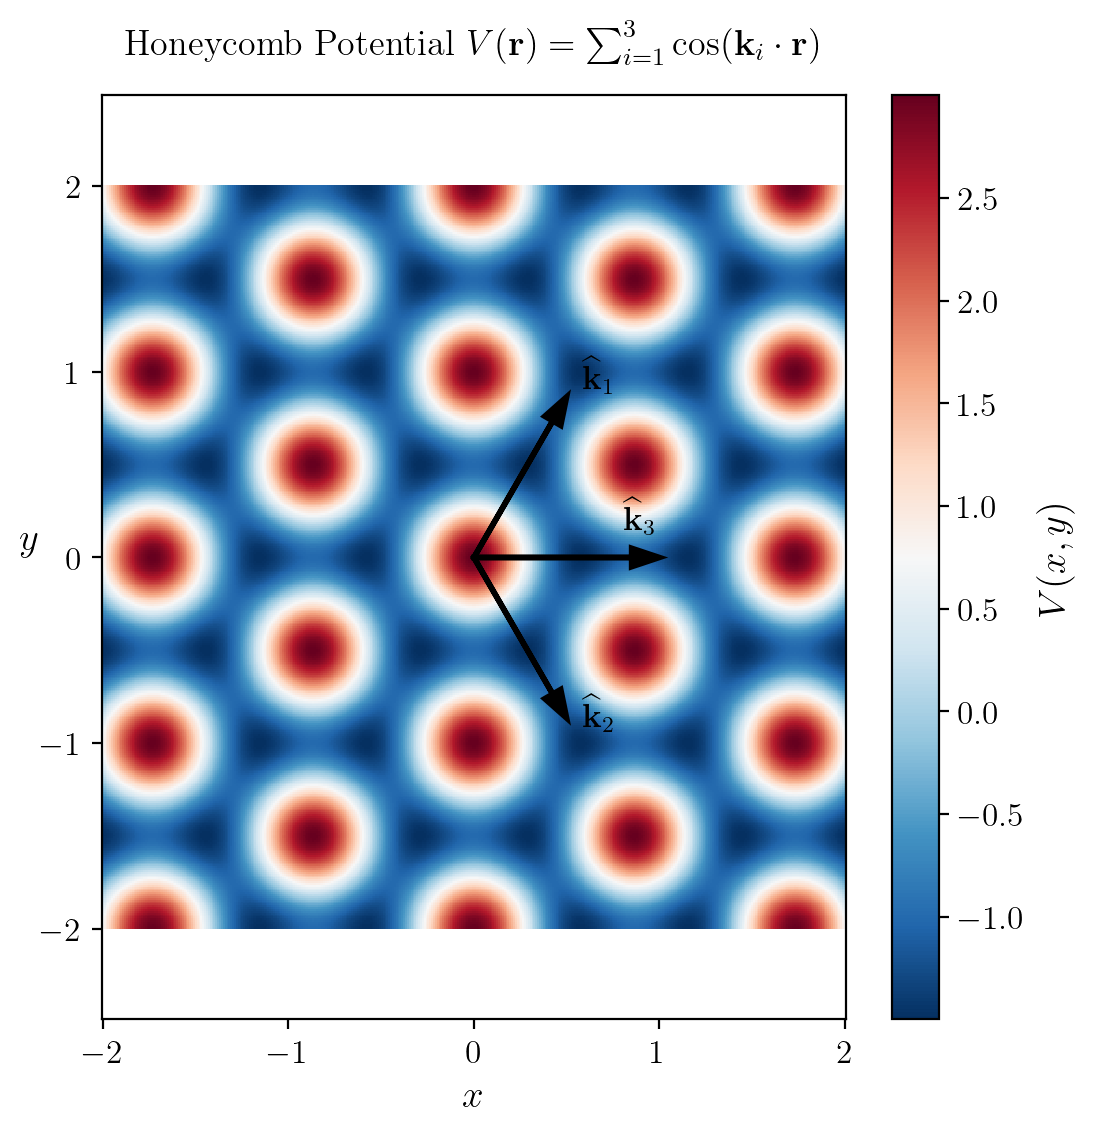

In [8]:
n = 400
x = torch.linspace(-2, 2, n, device=device)
y = torch.linspace(-2, 2, n, device=device)
X, Y = torch.meshgrid(x, y, indexing="xy")

a = 1.0
G = torch.tensor(4*np.pi / (np.sqrt(3)*a), dtype=torch.float32, device=device)

k1 = torch.tensor([0.5*G,  np.sqrt(3)/2*G], dtype=torch.float32, device=device)
k2 = torch.tensor([0.5*G, -np.sqrt(3)/2*G], dtype=torch.float32, device=device)
k3 = torch.tensor([G,      0.0          ], dtype=torch.float32, device=device)
G_vecs = [k1, k2, k3]

V = honeycomb_potential(X, Y, V0=1.0, a=1.0).cpu().numpy()

fig, ax = plt.subplots(figsize=(6,6))
plt.pcolormesh(X.cpu(), Y.cpu(), V, cmap="RdBu_r", shading="auto")
plt.axis("equal")
plt.title(r"Honeycomb Potential $V(\mathbf{r}) = \sum_{i=1}^3 \cos(\mathbf{k}_i\cdot\mathbf{r})$", fontsize=13, pad=15)

plt.xlabel("$x$")
 # need to rotate y label so it is horizontal do this by rotation
plt.ylabel("$y$", rotation=0)
plt.colorbar(label="$V(x,y)$")

# Overlay reciprocal vectors (scaled for clarity)
origin = np.array([[0,0]])
for i, g in enumerate(G_vecs):
    g_np = g.detach().cpu().numpy()
    scale = 1/norm(g_np) #scale down G by its norm for plotting
    ax.arrow(0, 0, scale*g_np[0], scale*g_np[1],
             color='k', lw=2, head_width=0.1, length_includes_head=True)
    if i != 2:
        ax.text(scale*1.05*g_np[0]+0.05, scale*1.05*g_np[1],
                rf"$\widehat{{\mathbf{{k}}}}_{i+1}$", fontsize=12, color='k')
    else:
        ax.text(scale*1.05*g_np[0]-0.25, scale*1.05*g_np[1]+0.15,
                rf"$\widehat{{\mathbf{{k}}}}_{3}$", fontsize=12, color='k')
        
plt.axis('equal')                     # ensures x/y scaling is equal
plt.xlim(X.min(), X.max())            # match box to data range
plt.ylim(Y.min(), Y.max())
plt.gca().set_box_aspect(1)

plt.show()

In [9]:
def plot_honeycomb_with_cell(V_fn, a1, a2, V0=1.0, a=1.0, n=400):
    x = torch.linspace(-2*a, 2*a, n, device=device)
    y = torch.linspace(-2*a, 2*a, n, device=device)
    X, Y = torch.meshgrid(x, y, indexing="xy")

    V = V_fn(X, Y, V0=V0, a=a).detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(6,6))
    pcm = ax.pcolormesh(X.cpu(), Y.cpu(), V, cmap="RdBu_r", shading="auto")

    # draw primitive parallelogram
    A1 = a1.cpu().numpy()
    A2 = a2.cpu().numpy()
    cell = np.array([[0,0], A1, A1+A2, A2, [0,0]])
    ax.plot(cell[:,0], cell[:,1], "k--", lw=1.2)

    ax.set_aspect("equal")
    plt.colorbar(pcm, ax=ax, label=r"$V(x,y)$")
    ax.set_title("Honeycomb Potential \& Primitive Cell")
    plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\&'
<>:19: SyntaxWarning: invalid escape sequence '\&'
/tmp/ipykernel_2098519/2946514332.py:19: SyntaxWarning: invalid escape sequence '\&'
  ax.set_title("Honeycomb Potential \& Primitive Cell")


In [10]:
plot_honeycomb_with_cell(honeycomb_potential, a1, a2, V0=1.0, a=1.0, n=400)

NameError: name 'a1' is not defined

In [11]:
def D(var, f):
    """First derivative df/dvar using autograd."""
    return torch.autograd.grad(
        f, var, 
        grad_outputs=torch.ones_like(f),
        create_graph=True
    )[0]

def D2(var, f):
    """Second derivative ddf/dvardvar."""
    df = D(var, f)
    return torch.autograd.grad(
        df, var, 
        grad_outputs=torch.ones_like(df),
        create_graph=True
    )[0]
    

def laplacian(psi, x, y):
    """
    psi: complex tensor (N,1)
    x,y: real tensors (N,1) with requires_grad=True
    """
    psi_real = psi.real
    psi_imag = psi.imag

    psi_xx_real = D2(x, psi_real)
    psi_xx_imag = D2(x, psi_imag)
    psi_yy_real = D2(y, psi_real)
    psi_yy_imag = D2(y, psi_imag)

    psi_xx = psi_xx_real + 1j * psi_xx_imag
    psi_yy = psi_yy_real + 1j * psi_yy_imag
    return psi_xx + psi_yy   # (N,1)

In [12]:
class BlochPINN(nn.Module):
    """
    Multi-band Bloch PINN:
    - bloch net learns periodic Bloch amplitude u_b(x,y;k)
    - energy net learns band energies E_b(k)
    """
    def __init__(self, B=4, f_width=128, f_depth=6,
                 e_width=64, e_depth=3):
        super().__init__()
        self.B = B
        
        #energy net
        self.e_in = nn.Linear(2, e_width)  # (kx,ky)
        self.e_hidden = nn.ModuleList(
            [nn.Linear(e_width, e_width) for _ in range(e_depth)]
        )
        self.e_out = nn.Linear(e_width, B)  # predicts B energies
        
        self.e_act = nn.SiLU()
        
        #bloch net
        self.f_in = nn.Linear(4, f_width)  # (x,y,kx,ky)
        self.f_hidden = nn.ModuleList(
            [nn.Linear(f_width, f_width) for _ in range(f_depth)]
        )
        self.f_out = nn.Linear(f_width, 2*B)  # (uR,uI) for each band
        
        self.f_act = nn.SiLU()

    def forward(self, x, y, kx, ky):
        """
        Returns:
            uR, uI: (N,B) periodic Bloch amplitudes
            E:     (N,B) energy values at k
        """
        # pass energynet
        k = torch.cat([kx, ky], dim=1)   # (N,2)
        e = self.e_act(self.e_in(k))
        for layer in self.e_hidden:
            e = self.e_act(layer(e))
        E = self.e_out(e)                # (N,B)
        
        # pass blochnet
        inp = torch.cat([x, y, kx, ky], dim=1)  # (N,4)
        f = self.f_act(self.f_in(inp))
        for layer in self.f_hidden:
            f = self.f_act(layer(f))
        
        out = self.f_out(f)              # (N,2B)
        out = out.view(-1, self.B, 2)    # (N,B,2)
        
        uR = out[:,:,0]                  # (N,B)
        uI = out[:,:,1]                  # (N,B)
        
        return uR, uI, E
    
def get_psi(uR, uI, x, y, kx, ky):
    """
    uR, uI: (N,B)
    x,y,kx,ky: (N,1)
    returns psi: complex (N,B)
    """
    k_dot_r = kx * x + ky * y  # (N,1)

    coskr = torch.cos(k_dot_r)
    sinkr = torch.sin(k_dot_r)

    psi_real = uR * coskr - uI * sinkr  # multiplication broadcast over B
    psi_imag = uR * sinkr + uI * coskr

    psi = torch.complex(psi_real, psi_imag)  # (N,B)
    return psi
    
def bloch_pde_loss(model, x, y, kx, ky, V_fn, cell_area=1.0):
    # potential
    Vxy = V_fn(x, y)  # (N,1)

    # network outputs
    uR, uI, E = model(x, y, kx, ky)  # uR,uI: (N,B), E: (N,B)

    # full Bloch wavefunctions psi_b
    psi = get_psi(uR, uI, x, y, kx, ky)  # (N,B)

    B = uR.shape[1]
    loss_bands = []

    for b in range(B):
        psi_b = psi[:, b:b+1]           # (N,1)
        E_b   = E[:,  b:b+1]            # (N,1)

        lap_b = laplacian(psi_b, x, y)  # (N,1) complex

        # residual: f_b = E_b psi_b + 1/2 laplacian psi_b - V psi_b
        f_b = E_b * psi_b + 0.5 * lap_b - Vxy * psi_b

        loss_b = (f_b.real.pow(2) + f_b.imag.pow(2)).mean()
        loss_bands.append(loss_b)

    # mean over bands
    return sum(loss_bands) / B

def norm_loss(model, kx, ky, a1, a2, n_r=300):
    N_k = kx.shape[0]
    A = torch.abs(a1[0]*a2[1] - a1[1]*a2[0])

    losses = []

    for i in range(N_k):
        # sample r for THIS k
        x_r, y_r = sample_cell(n_r, a1, a2)

        kx_i = kx[i:i+1].repeat(n_r,1)
        ky_i = ky[i:i+1].repeat(n_r,1)

        uR, uI, E = model(x_r, y_r, kx_i, ky_i)
        psi = get_psi(uR, uI, x_r, y_r, kx_i, ky_i)

        # per-band normalization
        norm_i = psi.abs().pow(2).mean(dim=0) * A
        losses.append(((norm_i - 1)**2).mean())

    return torch.stack(losses).mean()

def sample_cell(n_samples, a1, a2):
    """
    Sample points uniformly inside the parallelogram spanned by (a1,a2).
    """
    s1 = torch.rand(n_samples, 1, device=device)
    s2 = torch.rand(n_samples, 1, device=device)

    x = s1 * a1[0] + s2 * a2[0]
    y = s1 * a1[1] + s2 * a2[1]

    x.requires_grad_(True)
    y.requires_grad_(True)
    return x, y

def bandwise_grad(var, f):
    """
    var: (N,1), f: (N,B)
    returns grads: (N,B) with grad wrt var for each band separately.
    """
    grads = []
    B = f.shape[1]
    for b in range(B):
        fb = f[:, b:b+1]                    # (N,1)
        gb = D(var, fb)                     # (N,1)
        grads.append(gb)
    return torch.cat(grads, dim=1)          # (N,B)

def lattice_bc_loss(model, kx, ky, a1, a2, n_pts=200):
    """
    Enforces periodicity of u(x,y;k) and its derivative along both
    lattice directions a1, a2 by matching opposite edges of the cell.
    """
    N_k = kx.shape[0]
    losses = []

    for i in range(N_k):
        # ============================
        # A1 PERIODICITY (edges along a2)
        # ============================
        t = torch.rand(n_pts // 2, 1, device=device)

        # edge at r = t a2  and r + a1
        x0 = t * a2[0]
        y0 = t * a2[1]

        x1 = x0 + a1[0]
        y1 = y0 + a1[1]

        x = torch.cat([x0, x1], dim=0).requires_grad_(True)
        y = torch.cat([y0, y1], dim=0).requires_grad_(True)

        kx_i = kx[i:i+1].repeat(n_pts, 1)
        ky_i = ky[i:i+1].repeat(n_pts, 1)

        uR, uI, _ = model(x, y, kx_i, ky_i)    # (n_pts, B)
        u = torch.complex(uR, uI)              # (n_pts, B)

        duR = bandwise_grad(x, uR) + bandwise_grad(y, uR)  # (n_pts,B)
        duI = bandwise_grad(x, uI) + bandwise_grad(y, uI)  # (n_pts,B)
        du_complex = torch.complex(duR, duI)               # (n_pts,B)

        u0, u1   = u[:n_pts//2],       u[n_pts//2:]
        du0, du1 = du_complex[:n_pts//2], du_complex[n_pts//2:]

        diff_u  = u1  - u0
        diff_du = du1 - du0

        L_a1_val = (diff_u.real**2 + diff_u.imag**2).mean()
        L_a1_der = (diff_du.real**2 + diff_du.imag**2).mean()
        L_a1 = L_a1_val + L_a1_der

        # ============================
        # A2 PERIODICITY (edges along a1)
        # ============================
        t = torch.rand(n_pts // 2, 1, device=device)

        x0 = t * a1[0]
        y0 = t * a1[1]

        x1 = x0 + a2[0]
        y1 = y0 + a2[1]

        x = torch.cat([x0, x1], dim=0).requires_grad_(True)
        y = torch.cat([y0, y1], dim=0).requires_grad_(True)

        kx_i = kx[i:i+1].repeat(n_pts, 1)
        ky_i = ky[i:i+1].repeat(n_pts, 1)

        uR, uI, _ = model(x, y, kx_i, ky_i)
        u = torch.complex(uR, uI)

        duR = bandwise_grad(x, uR) + bandwise_grad(y, uR)
        duI = bandwise_grad(x, uI) + bandwise_grad(y, uI)
        du_complex = torch.complex(duR, duI)

        u0, u1   = u[:n_pts//2],       u[n_pts//2:]
        du0, du1 = du_complex[:n_pts//2], du_complex[n_pts//2:]

        diff_u  = u1  - u0
        diff_du = du1 - du0

        L_a2_val = (diff_u.real**2 + diff_u.imag**2).mean()
        L_a2_der = (diff_du.real**2 + diff_du.imag**2).mean()
        L_a2 = L_a2_val + L_a2_der

        losses.append(L_a1 + L_a2)

    return torch.stack(losses).mean()

def ortho_loss(model, kx, ky, a1, a2, n_r=300):
    """
    Efficient orthogonality loss using matrix mult
    """
    N_k = kx.shape[0]
    A = torch.abs(a1[0]*a2[1] - a1[1]*a2[0])

    losses = []

    for i in range(N_k):

        # Sample r for this k
        x_r, y_r = sample_cell(n_r, a1, a2)

        # Repeat k
        kx_i = kx[i:i+1].repeat(n_r, 1)
        ky_i = ky[i:i+1].repeat(n_r, 1)

        # Compute psi: shape (n_r, B)
        uR, uI, _ = model(x_r, y_r, kx_i, ky_i)
        psi = get_psi(uR, uI, x_r, y_r, kx_i, ky_i)   # (n_r, B)

        # Make psi as (n_r, B) complex
        # Compute Gram matrix: G_{bc} = <psi_b, psi_c>
        # (psi^H psi) → shape (B, B)
        G = (psi.conj().T @ psi) * (A / n_r)  # area normalization

        # Take off-diagonal entries only
        off_diag = G - torch.diag(torch.diag(G))

        # Frobenius norm of off-diagonal entries
        loss_i = (off_diag.real**2 + off_diag.imag**2).sum()

        losses.append(loss_i)

    return torch.stack(losses).mean()

In [13]:
a = 1.0
q = torch.tensor(4*np.pi / (np.sqrt(3)*a), dtype=torch.float32, device=device)

# Reciprocal vectors
k1 = torch.tensor([0.5*q,  np.sqrt(3)/2*q], dtype=torch.float32, device=device)
k2 = torch.tensor([0.5*q, -np.sqrt(3)/2*q], dtype=torch.float32, device=device)

a1 = torch.tensor([a*np.sqrt(3)/2,  a*1/2], dtype=torch.float32, device=device)
a2 = torch.tensor([a*np.sqrt(3)/2, -a*1/2], dtype=torch.float32, device=device)

# High symmetry points
Gamma = torch.zeros(1, 2, dtype=torch.float32, device=device)   # (1,2)
K     = ((2*k1 + k2) / 3.0).reshape(1,2)                        # (1,2)
M     = ((k1 + k2) / 2.0).reshape(1,2)                           # (1,2)

kx_G = Gamma[:,0:1]
ky_G = Gamma[:,1:2]

kx_K = K[:,0:1]
ky_K = K[:,1:2]

kx_M = M[:,0:1]
ky_M = M[:,1:2]

def sample_IBZ(n_k):
    """Sample n_k points uniformly in the triangular IBZ wedge gamma–K–M."""
    s1 = torch.rand(n_k, 1, device=device)
    s2 = torch.rand(n_k, 1, device=device)

    # reflect to keep inside triangle
    mask = (s1 + s2 > 1)
    s1[mask], s2[mask] = 1 - s1[mask], 1 - s2[mask]

    k = Gamma + s1*(K-Gamma) + s2*(M-Gamma)
    kx = k[:,0:1].clone().detach().requires_grad_(True)
    ky = k[:,1:2].clone().detach().requires_grad_(True)
    return kx, ky

In [14]:
def train_bloch_pinn_joint_k(
    model,
    V_fn,
    a1, a2,
    n_epochs=3000,
    batch_size=5000,
    alpha_norm=1.0,
    alpha_bc=5.0,
    alpha_ortho=1.0,
    lr=2e-3,
    n_r_norm=150,
    n_r_ortho=150,
    n_r_bc=500,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # (optional) scheduler — made slower and less aggressive
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    #     optimizer, T_max=5000, eta_min=5e-4
    # )

    history = {"total": [], "pde": [], "norm": [], "bc": [], "ortho": []}

    for epoch in range(n_epochs):

        # ------------------------------------------
        # 1) PDE loss (full 5000 batch)
        # ------------------------------------------
        x, y = sample_cell(batch_size, a1, a2)
        kx, ky = sample_IBZ(batch_size)

        loss_pde = bloch_pde_loss(model, x, y, kx, ky, V_fn)

        # ------------------------------------------
        # 2) Auxiliary losses use k-batches
        # ------------------------------------------
        kx_norm,  ky_norm  = sample_IBZ(32)
        kx_ortho, ky_ortho = sample_IBZ(32)
        kx_bc,    ky_bc    = sample_IBZ(32)

        loss_norm  = norm_loss(model,  kx_norm,  ky_norm,  a1, a2, n_r=n_r_norm)
        loss_ortho = ortho_loss(model, kx_ortho, ky_ortho, a1, a2, n_r=n_r_ortho)
        loss_bc    = lattice_bc_loss(model, kx_bc, ky_bc, a1, a2, n_pts=n_r_bc)

        # ------------------------------------------
        # TOTAL LOSS
        # ------------------------------------------
        total = (
            loss_pde
            + alpha_norm  * loss_norm
            + alpha_bc    * loss_bc
            + alpha_ortho * loss_ortho
        )

        optimizer.zero_grad()
        total.backward()
        optimizer.step()
        # scheduler.step()

        # ------------------------------------------
        # Logging
        # ------------------------------------------
        history["total"].append(total.item())
        history["pde"].append(loss_pde.item())
        history["norm"].append(loss_norm.item())
        history["bc"].append(loss_bc.item())
        history["ortho"].append(loss_ortho.item())

        if epoch % 200 == 0:
            print(f"[{epoch}] total={total.item():.3e} PDE={loss_pde.item():.3e}")

    return history

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


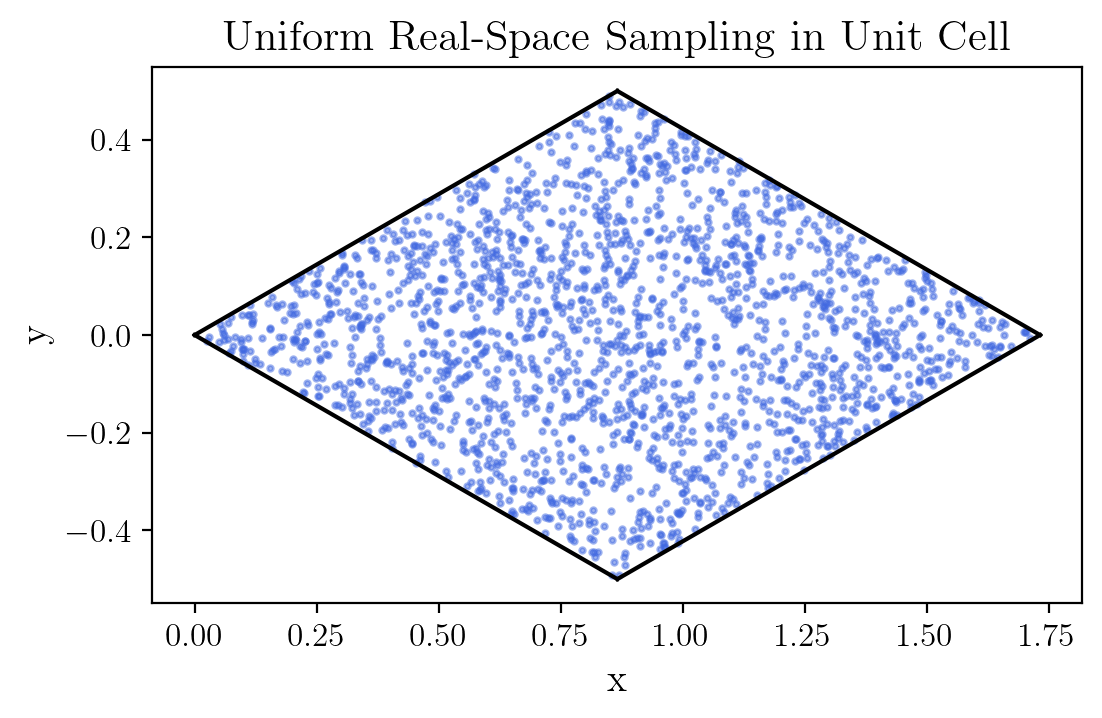

In [13]:
def plot_cell_samples(a1, a2, n=2000):
    x, y = sample_cell(n, a1, a2)
    x = x.detach().cpu().numpy()
    y = y.detach().cpu().numpy()

    # cell corners
    O  = np.array([0,0])
    A1 = a1.cpu().numpy()
    A2 = a2.cpu().numpy()
    A12 = A1 + A2

    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x, y, s=4, alpha=0.5, color="royalblue")
    
    ax.plot([O[0],A1[0]],[O[1],A1[1]], 'k-')
    ax.plot([O[0],A2[0]],[O[1],A2[1]], 'k-')
    ax.plot([A1[0],A12[0]],[A1[1],A12[1]], 'k-')
    ax.plot([A2[0],A12[0]],[A2[1],A12[1]], 'k-')
    
    ax.set_title("Uniform Real-Space Sampling in Unit Cell")
    ax.set_aspect("equal")
    plt.xlabel("x"); plt.ylabel("y")
    plt.show()

plot_cell_samples(a1, a2, n=2000)

In [1]:
model = BlochPINN(B=1).to(device)
model.load_state_dict(torch.load("results/bloch_model.pt", map_location=device))
model.eval()

# High-symmetry points already on device: Gamma, K, M

t1 = torch.linspace(0, 1, 80, device=device).unsqueeze(1)
t2 = torch.linspace(0, 1, 80, device=device).unsqueeze(1)
t3 = torch.linspace(0, 1, 80, device=device).unsqueeze(1)

path = torch.cat([
    t1*K + (1 - t1)*Gamma,
    t2*M + (1 - t2)*K,
    t3*Gamma + (1 - t3)*M,
], dim=0)  # (240,2) on GPU

kx = path[:, 0:1]
ky = path[:, 1:2]

# Dummy x,y — keep same device
x = torch.zeros_like(kx)
y = torch.zeros_like(ky)

with torch.no_grad():
    _, _, E = model(x, y, kx, ky)

E = E.cpu().numpy()

NameError: name 'BlochPINN' is not defined

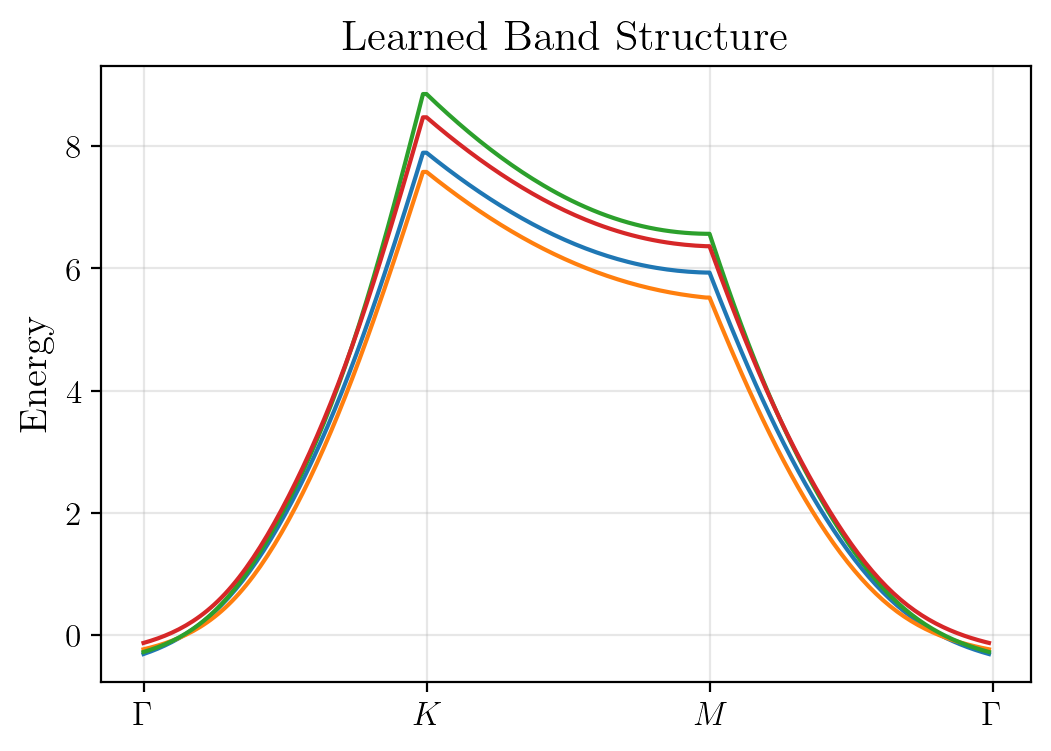

In [15]:
plt.figure(figsize=(6,4))
for b in range(E.shape[1]):
    plt.plot(E[:,b])
plt.xticks([0,80,160,240], [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$"])
plt.ylabel("Energy")
plt.title("Learned Band Structure")
plt.grid(alpha=0.3)
plt.show()

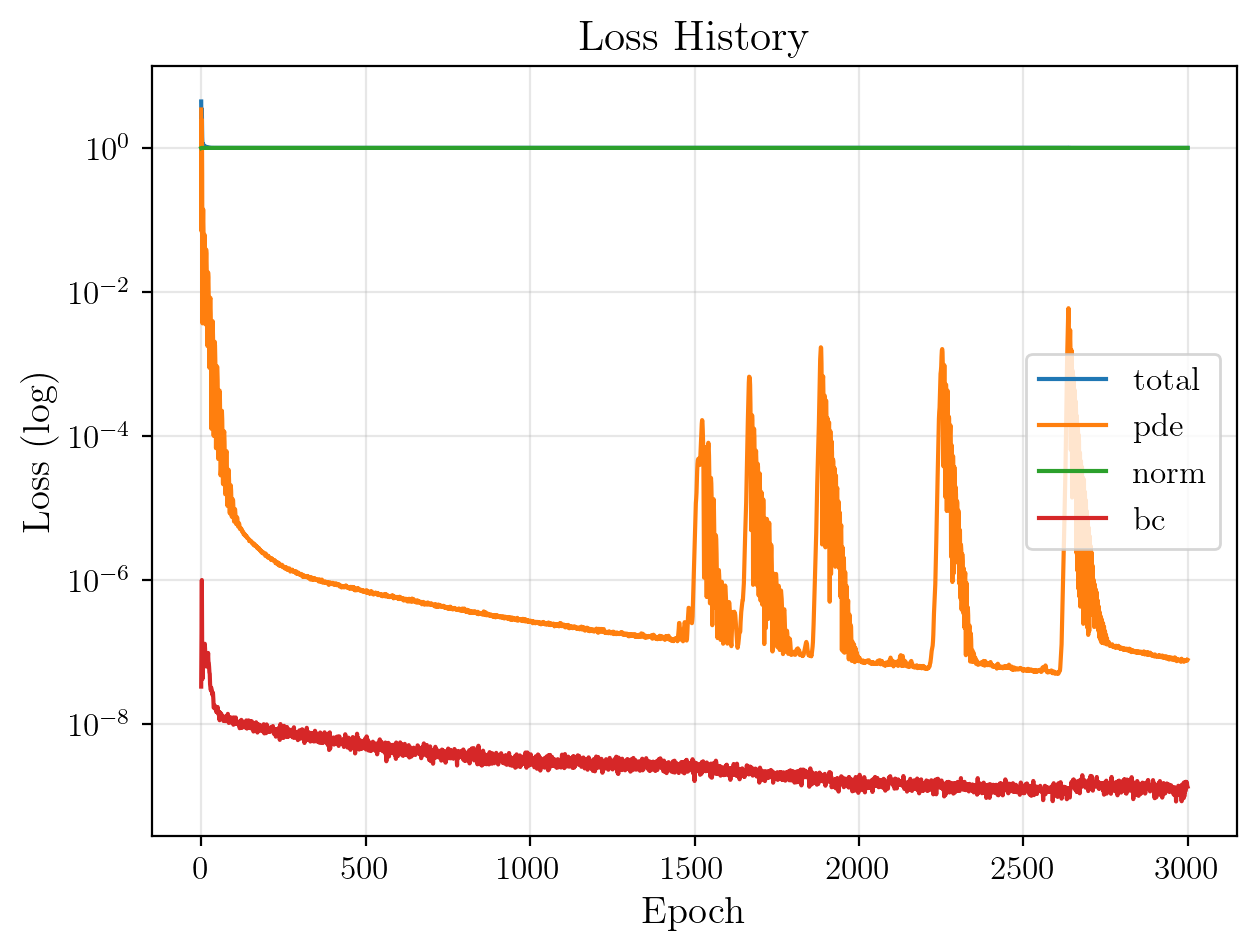

In [4]:
hist = np.load("results/loss_history.npy", allow_pickle=True).item()

plt.figure(figsize=(7,5))
for key in hist:
    plt.plot(hist[key], label=key)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Loss History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
def plot_bloch_series(
    model, 
    k_list,              # list of (label, kvec) where label is mathtext string
    band=0,              # internal 0-index
    pts=90,
    cmap="magma"
):
    model.eval()
    band_label = band + 1  # human-friendly band index

    # structured sampling inside unit cell
    lin = torch.linspace(0, 1, pts, device=device)
    s1, s2 = torch.meshgrid(lin, lin, indexing='ij')

    X = s1 * a1[0] + s2 * a2[0]
    Y = s1 * a1[1] + s2 * a2[1]

    Xf = X.reshape(-1,1)
    Yf = Y.reshape(-1,1)

    n = len(k_list)
    fig, axes = plt.subplots(
        1, n,
        figsize=(2.2*n, 2.2),
        dpi=180,
        constrained_layout=True
    )

    if n == 1:
        axes = [axes]

    for ax, (label, kvec) in zip(axes, k_list):
        kvec = kvec.squeeze()
        kx = torch.full_like(Xf, kvec[0])
        ky = torch.full_like(Yf, kvec[1])

        with torch.no_grad():
            uR, uI, _ = model(Xf, Yf, kx, ky)

        u = uR[:, band] + 1j*uI[:, band]
        prob = (u.abs()**2).reshape(pts, pts).cpu()

        pcm = ax.pcolormesh(
            X.cpu(), Y.cpu(), prob,
            shading="auto", cmap=cmap
        )
        ax.set_aspect("equal")

        # primitive cell outline
        cell = np.array([
            [0,0],
            a1.cpu().numpy(),
            (a1+a2).cpu().numpy(),
            a2.cpu().numpy(),
            [0,0]
        ])
        ax.plot(cell[:,0], cell[:,1], "w-", linewidth=0.7)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(fr"{label}, Band {band_label}", fontsize=9)

    cbar = fig.colorbar(
        pcm,
        ax=axes,
        shrink=0.82,
        location="right",
        pad=0.03
    )
    cbar.set_label(r"$|u(\mathbf{r},\mathbf{k})|^2$", fontsize=9)

    plt.show()

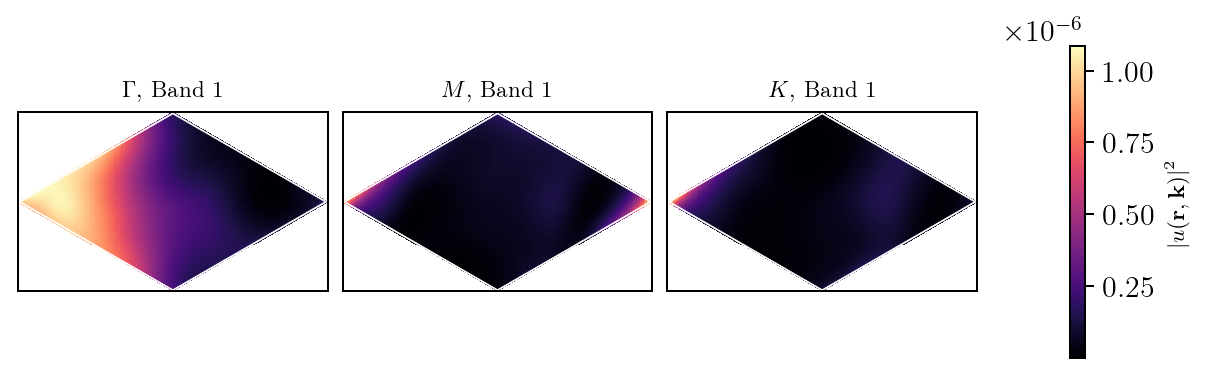

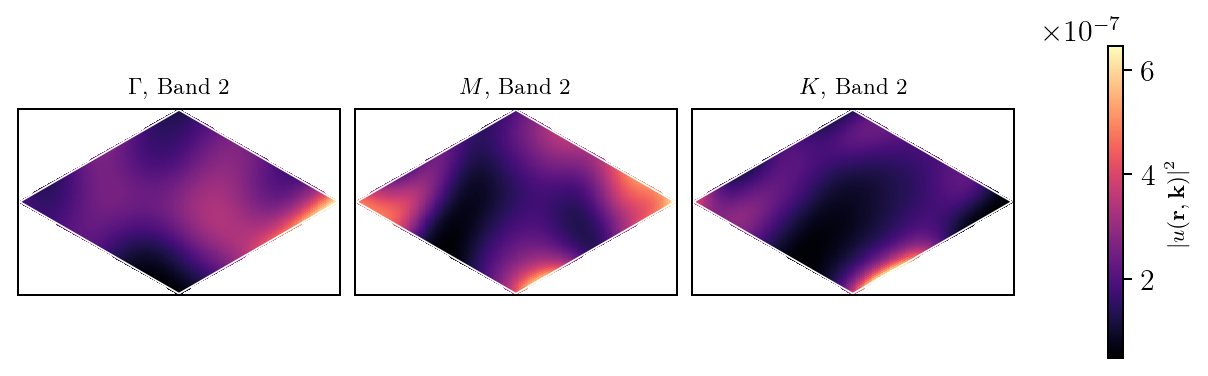

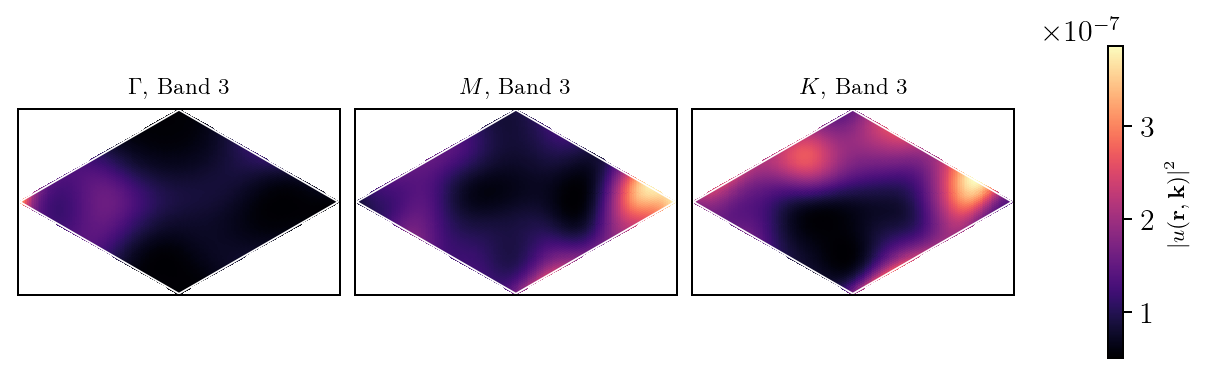

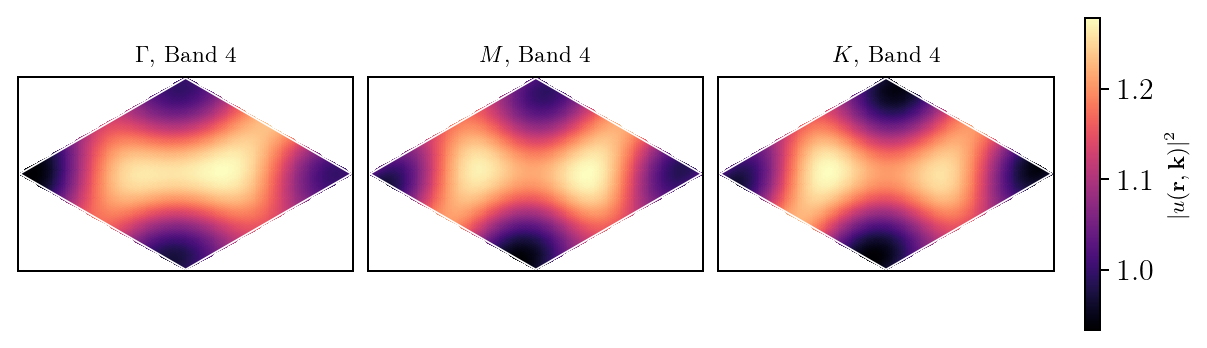

In [34]:
for b in range(4):
    plot_bloch_series(model, k_points, band=b)

In [16]:
def plot_bloch_grid(
    model,
    bands=(0,1,2,3),
    pts=90,
    cmap="magma"
):
    model.eval()

    # unit-cell sampling
    lin = torch.linspace(0, 1, pts, device=device)
    s1, s2 = torch.meshgrid(lin, lin, indexing='ij')
    X = s1 * a1[0] + s2 * a2[0]
    Y = s1 * a1[1] + s2 * a2[1]
    Xf, Yf = X.reshape(-1,1), Y.reshape(-1,1)

    R = len(bands)
    C = len(k_points)

    fig = plt.figure(figsize=(2.2*C, 2.0*R), dpi=180)
    gs = GridSpec(R, C, wspace=0.07, hspace=0.10)

    all_rows = []

    for row, band in enumerate(bands):
        band_label = band + 1
        row_axes = []

        for col, (label, kvec) in enumerate(k_points):
            ax = fig.add_subplot(gs[row, col])
            row_axes.append(ax)

            kvec = kvec.squeeze()
            kx = torch.full_like(Xf, kvec[0])
            ky = torch.full_like(Yf, kvec[1])

            with torch.no_grad():
                uR, uI, _ = model(Xf, Yf, kx, ky)

            u = uR[:, band] + 1j*uI[:, band]
            prob = (u.abs()**2).reshape(pts, pts).cpu()

            pcm = ax.pcolormesh(
                X.cpu(), Y.cpu(), prob,
                shading="auto", cmap=cmap
            )
            ax.set_aspect("equal")

            # primitive cell outline
            cell = np.array([
                [0,0],
                a1.cpu().numpy(),
                (a1+a2).cpu().numpy(),
                a2.cpu().numpy(),
                [0,0]
            ])
            ax.plot(cell[:,0], cell[:,1], "w-", linewidth=0.7)

            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(fr"{label}", fontsize=10)
            if col == 0:
                ax.set_ylabel(fr"Band {band_label}", fontsize=10)

        all_rows.append((row_axes, pcm))   
    
    for row_axes, pcm in all_rows:
        cbar = fig.colorbar(
            pcm,
            ax=row_axes,
            location="right",
            shrink=0.85,
            pad=0.02
        )
        cbar.set_label(r"$|u(\mathbf{r},\mathbf{k})|^2$", fontsize=11)

    plt.show()

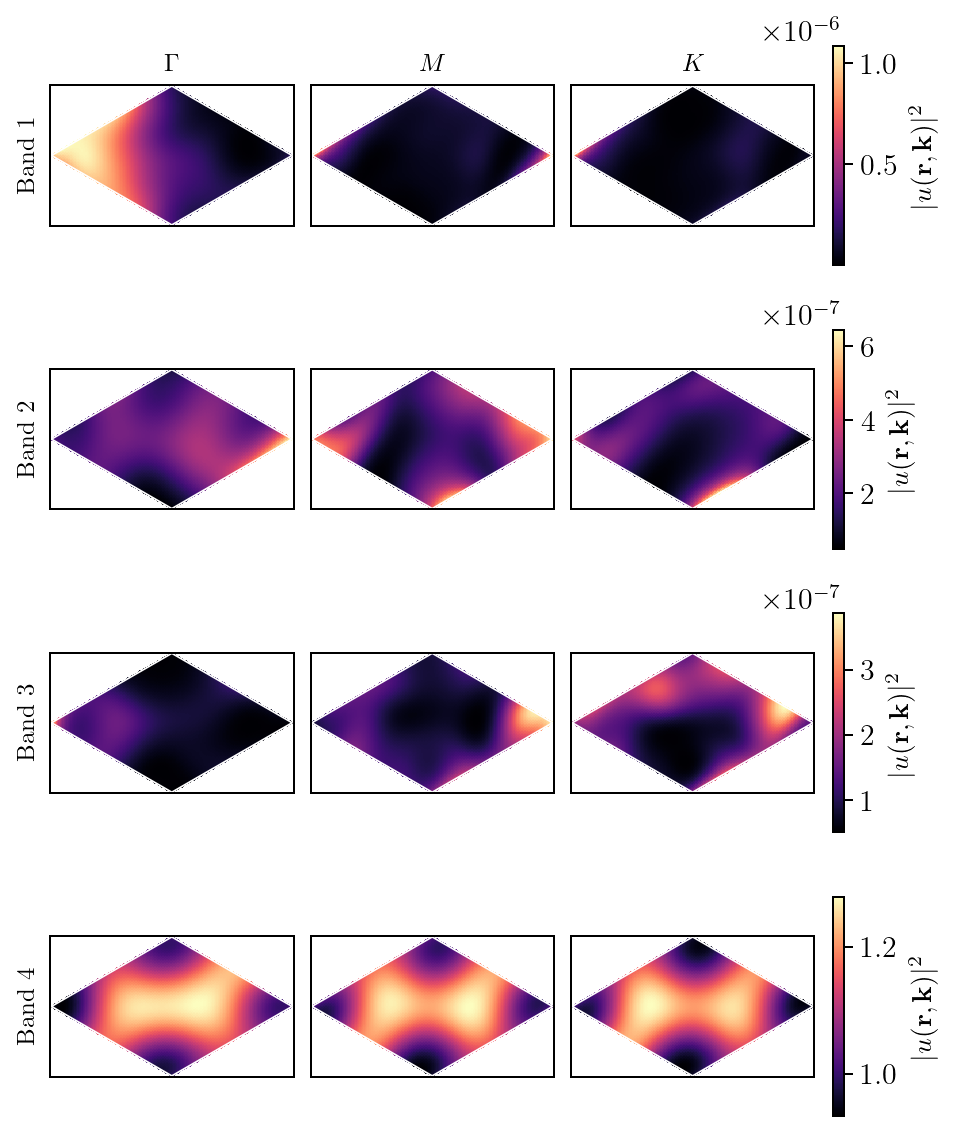

In [41]:
plot_bloch_grid(model, bands=range(4))

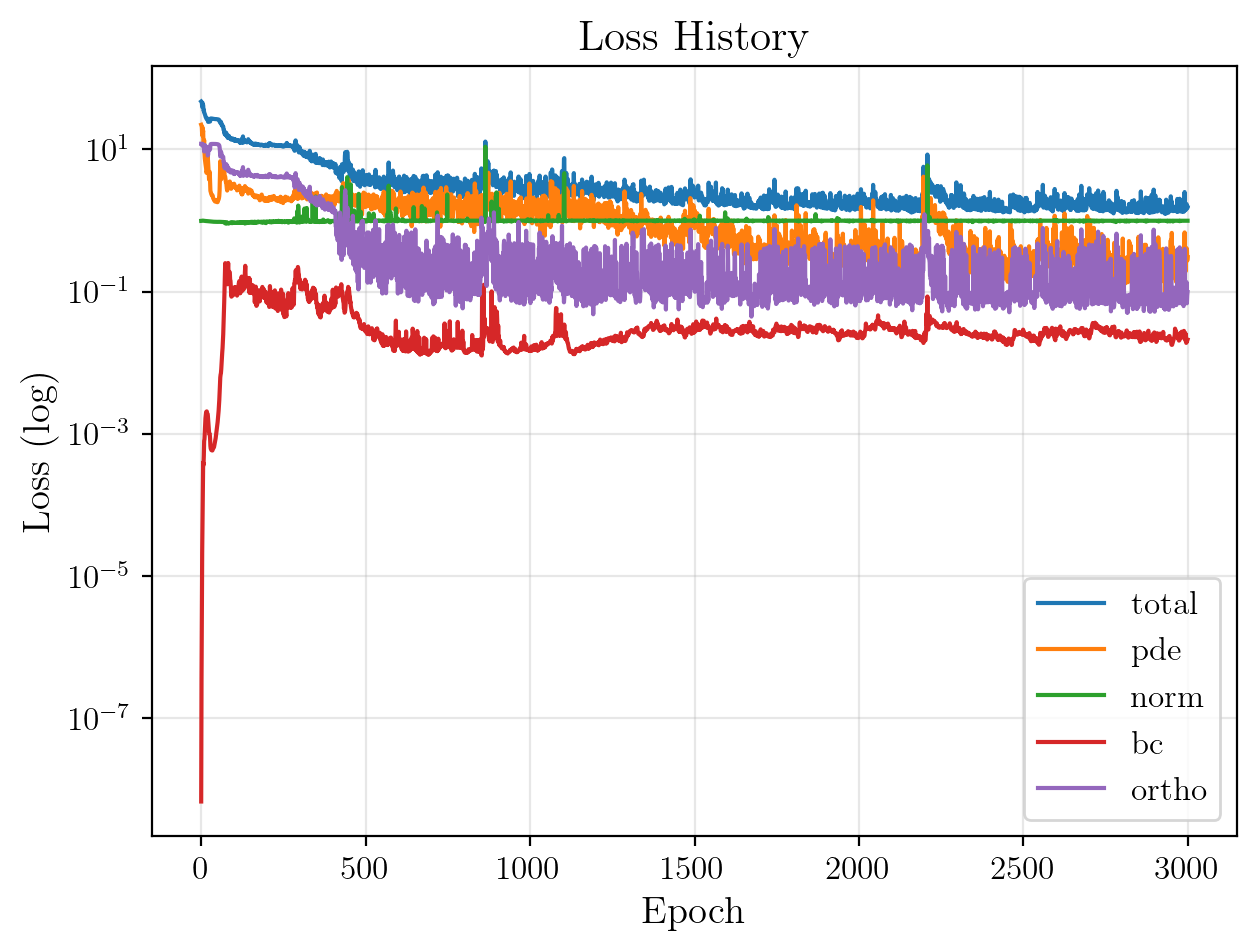

In [3]:
hist = np.load("results/loss_history.npy", allow_pickle=True).item()

plt.figure(figsize=(7,5))
for key in hist:
    plt.plot(hist[key], label=key)

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Loss History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()